##### The idea of this notebook is to intersect the genebody obtained from DeSeq2 to the chromatin loop anchors and make sense of the biological context of the project

In [1]:
import pandas as pd
from pybedtools import BedTool

In [2]:
# All the file loading
# Load genebody
genebody_up = BedTool("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed")
genebody_down = BedTool("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed")
# loops -mega ctrl + cpi
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv", sep=",")
#loops_short = loops[['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']]
loops = pd.DataFrame(loops)
# splitting loops to their anchors
anchor1 = BedTool.from_dataframe(loops[['chr1', 'start1', 'end1']])
anchor2 = BedTool.from_dataframe(loops[['chr2', 'start2', 'end2']])

In [3]:
loops

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.188543,0.024018,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN
1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,...,0.566125,0.063427,0.6135,0.0578,NaN,NaN,NaN,NaN,NaN,NaN
2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,...,0.188543,0.044699,0.6525,0.0102,NaN,NaN,NaN,NaN,NaN,NaN
3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.024769,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN
4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.042592,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,...,0.188543,0.026824,0.4545,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987
32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,...,0.249019,0.130330,0.4609,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987
32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,...,0.241160,0.123878,0.4195,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464
32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,...,0.214433,0.112741,0.3788,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489


In [4]:
# Extend genebody regions for somewhat good intersection
genebody_up_slop = genebody_up.slop(b=500, genome='hg38')
genebody_down_slop = genebody_down.slop(b=500, genome='hg38')

In [5]:
genebody_df = genebody_up.to_dataframe(names=["chrom", "start", "end", "gene_id", "score", "strand"])
print(genebody_df.duplicated().sum())  # total row duplicates
print(genebody_df.duplicated(subset=["gene_id"]).sum())  # gene-level duplicates

0
0


In [6]:
len(genebody_df)

2146

In [7]:
anchor_df = anchor1.to_dataframe(names=["chrom", "start", "end"])
print(anchor_df.duplicated().sum())

8228


In [8]:
anchor_df = anchor2.to_dataframe(names=["chrom", "start", "end"])
print(anchor_df.duplicated().sum())

8555


###### Here the duplicates are (possibly) due to the fact that same anchor can be shared by different distinct loops

In [9]:
genebody_df = genebody_down.to_dataframe(names=["chrom", "start", "end", "gene_id", "score", "strand"])
print(genebody_df.duplicated().sum())  # total row duplicates
print(genebody_df.duplicated(subset=["gene_id"]).sum())  # gene-level duplicates

0
0


In [10]:
# tss overlsp with anchor 1 & 2

In [11]:
# function # wa, wb - true. filt. later
def intersect_genebody(tss_bed, anchor_bed, num_of_anchor, deg_label):
    df = tss_bed.intersect(anchor_bed, wa=True, wb=True).to_dataframe(names=[
    'genebody_chr', 'genebody_start', 'genebody_end', 'gene_id', 'score', 'strand',
    'anchor_chr', 'anchor_start', 'anchor_end'
    ])
    df['genebody_anchor'] = num_of_anchor
    df['deg_class'] = deg_label
    print(df.duplicated().sum())
    print(df.duplicated(subset=["gene_id", "anchor_start", "anchor_end"]).sum())

    return df

# todo: check tss_chr == anchor_chr

In [12]:
up1 = intersect_genebody(genebody_up_slop, anchor1, 1, 'upregulated_a1')
up2 = intersect_genebody(genebody_up_slop, anchor2, 2, 'upregulated_a2')
down1 = intersect_genebody(genebody_down_slop, anchor1, 1, 'downregulated_a1')
down2 = intersect_genebody(genebody_down_slop, anchor2, 2, 'downregulated_a2')

277
277
407
407
18
18
30
30


In [13]:
all = [up1, up2, down1, down2]
for deg_condition in all:
    print(len(deg_condition))

1678
1454
127
127


In [14]:
#combine into a single df
genebody_anchors_updown = pd.concat([up1, up2, down1, down2], ignore_index=True)
genebody_anchors_updown

,genebody_chr,genebody_start,genebody_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,genebody_anchor,deg_class
0,chr1,22710338,22891765,ENST00000544305.5,0,+,chr1,22762500,22767500,1,upregulated_a1
1,chr1,22710338,22922000,ENST00000374630.8,0,+,chr1,22762500,22767500,1,upregulated_a1
2,chr1,22710464,22922000,ENST00000400191.7,0,+,chr1,22762500,22767500,1,upregulated_a1
3,chr1,22710469,22914770,ENST00000374632.7,0,+,chr1,22762500,22767500,1,upregulated_a1
4,chr1,28369081,28459739,ENST00000633371.1,0,+,chr1,28402500,28407500,1,upregulated_a1
...,...,...,...,...,...,...,...,...,...,...,...
3381,chr12,68324620,68332881,ENST00000430606.3,0,-,chr12,68322500,68327500,2,downregulated_a2
3382,chr12,68324672,68332757,ENST00000545724.2,0,-,chr12,68322500,68327500,2,downregulated_a2
3383,chr17,82022804,82031651,ENST00000306688.8,0,+,chr17,82020000,82025000,2,downregulated_a2
3384,chr17,82022820,82025925,ENST00000583383.5,0,+,chr17,82020000,82025000,2,downregulated_a2


In [15]:
key_cols = ["gene_id", "anchor_chr", "anchor_start", "anchor_end"]
genebody_anchors_updown = genebody_anchors_updown.drop_duplicates(ignore_index=True, subset=key_cols)
len(genebody_anchors_updown)

2607

In [16]:
# drop score, strand
#tss_anchors_updown.drop(["score", "strand"], axis=1)


In [17]:
genebody_anchors_updown

,genebody_chr,genebody_start,genebody_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,genebody_anchor,deg_class
0,chr1,22710338,22891765,ENST00000544305.5,0,+,chr1,22762500,22767500,1,upregulated_a1
1,chr1,22710338,22922000,ENST00000374630.8,0,+,chr1,22762500,22767500,1,upregulated_a1
2,chr1,22710464,22922000,ENST00000400191.7,0,+,chr1,22762500,22767500,1,upregulated_a1
3,chr1,22710469,22914770,ENST00000374632.7,0,+,chr1,22762500,22767500,1,upregulated_a1
4,chr1,28369081,28459739,ENST00000633371.1,0,+,chr1,28402500,28407500,1,upregulated_a1
...,...,...,...,...,...,...,...,...,...,...,...
2602,chr12,68324620,68332881,ENST00000430606.3,0,-,chr12,68322500,68327500,2,downregulated_a2
2603,chr12,68324672,68332757,ENST00000545724.2,0,-,chr12,68322500,68327500,2,downregulated_a2
2604,chr17,82022804,82031651,ENST00000306688.8,0,+,chr17,82020000,82025000,2,downregulated_a2
2605,chr17,82022820,82025925,ENST00000583383.5,0,+,chr17,82020000,82025000,2,downregulated_a2


In [18]:
#This is a check to make sure that my merged_loop list didn't have duplicates. big scare moment it was. But gave 0 duplicates--yay! I used this file for XGBoost model
cols = [
    "chr1", "start1", "end1",
    "chr2", "start2", "end2",
    "name", "score", "strand1", "strand2"
]  # adjust if fewer or more columns
df = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/merged_loops.csv", sep="\t", header=None, names=cols)
print(df.duplicated().sum())  # full row dupes
print(df.duplicated(subset=["chr1", "start1", "end1", "chr2", "start2", "end2"]).sum())  # loop duplicates

0
0


In [19]:
# next to deal with the non overlapping anchor at the distal end

# Match to left side of loop (chr1/start1/end1)
match_chr1 = genebody_anchors_updown.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr1", "start1", "end1"],
    how="inner"
)
match_chr1["distal_chr"] = match_chr1["chr2"]
match_chr1["distal_start"] = match_chr1["start2"]
match_chr1["distal_end"] = match_chr1["end2"]

# Match to right side of loop (chr2/start2/end2)
match_chr2 = genebody_anchors_updown.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr2", "start2", "end2"],
    how="inner"
)
match_chr2["distal_chr"] = match_chr2["chr1"]
match_chr2["distal_start"] = match_chr2["start1"]
match_chr2["distal_end"] = match_chr2["end1"]

# Combine both matches
final_matched_loops = pd.concat([match_chr1, match_chr2], ignore_index=True)

# Keep shortest loop per genebody-anchor to prevent duplicates
final_matched_loops = final_matched_loops.sort_values("distance").drop_duplicates(
    subset=["gene_id", "anchor_chr", "anchor_start", "anchor_end"],
    keep="first",
    ignore_index=True
)

# Output
final_matched_loops


In [46]:
# Match left side of loop (chr1/start1/end1)
match_chr1 = genebody_anchors_updown.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr1", "start1", "end1"],
    how="inner"
)
match_chr1["anchor_side"] = "left"
match_chr1["distal_chr"] = match_chr1["chr2"]
match_chr1["distal_start"] = match_chr1["start2"]
match_chr1["distal_end"] = match_chr1["end2"]

# Match right side of loop (chr2/start2/end2)
match_chr2 = genebody_anchors_updown.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr2", "start2", "end2"],
    how="inner"
)
match_chr2["anchor_side"] = "right"
match_chr2["distal_chr"] = match_chr2["chr1"]
match_chr2["distal_start"] = match_chr2["start1"]
match_chr2["distal_end"] = match_chr2["end1"]

# Combine all matches
final_matched_loops = pd.concat([match_chr1, match_chr2], ignore_index=True)

# Do NOT deduplicate or filter
# (Optional) If you want one row per loop with multiple gene matches, groupby and aggregate separately

# Output
final_matched_loops

,genebody_chr,genebody_start,genebody_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,genebody_anchor,...,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,anchor_side,distal_chr,distal_start,distal_end
0,chr1,22710338,22891765,ENST00000544305.5,0,+,chr1,22762500,22767500,1,...,0.661962,0.655861,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500
1,chr1,22710338,22922000,ENST00000374630.8,0,+,chr1,22762500,22767500,1,...,0.661962,0.655861,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500
2,chr1,22710464,22922000,ENST00000400191.7,0,+,chr1,22762500,22767500,1,...,0.661962,0.655861,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500
3,chr1,22710469,22914770,ENST00000374632.7,0,+,chr1,22762500,22767500,1,...,0.661962,0.655861,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500
4,chr1,28369081,28459739,ENST00000633371.1,0,+,chr1,28402500,28407500,1,...,0.923284,0.774906,0.681454,0.743957,-0.148378,0.062503,left,chr1,28602500,28607500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381,chr12,68324620,68332881,ENST00000430606.3,0,-,chr12,68322500,68327500,2,...,NaN,NaN,NaN,NaN,NaN,NaN,right,chr12,67352500,67357500
3382,chr12,68324672,68332757,ENST00000545724.2,0,-,chr12,68322500,68327500,2,...,NaN,NaN,NaN,NaN,NaN,NaN,right,chr12,67352500,67357500
3383,chr17,82022804,82031651,ENST00000306688.8,0,+,chr17,82020000,82025000,2,...,0.902775,0.926363,0.809561,0.749275,0.023588,-0.060286,right,chr17,81955000,81960000
3384,chr17,82022820,82025925,ENST00000583383.5,0,+,chr17,82020000,82025000,2,...,0.902775,0.926363,0.809561,0.749275,0.023588,-0.060286,right,chr17,81955000,81960000


In [47]:
len(final_matched_loops)

3386

In [48]:
print(final_matched_loops.columns.tolist())


['genebody_chr', 'genebody_start', 'genebody_end', 'gene_id', 'score', 'strand', 'anchor_chr', 'anchor_start', 'anchor_end', 'genebody_anchor', 'deg_class', 'Unnamed: 0', 'chr1', 'start1', 'end1', 'chr2', 'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal', 'log2FC', 'log2FC_clipped', 'condition', 'distance', 'loop_id', 'comp_switch_A1', 'comp_switch_A2', 'loop_class', 'source', 'CTCF_signal', 'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal', 'GC_mean', 'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl', 'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2', 'anchor_side', 'distal_chr', 'distal_start', 'distal_end']


In [49]:
import pandas as pd

# Show all rows
#pd.set_option('display.max_rows', None)

# Show all columns
#pd.set_option('display.max_columns', None)

# Now display
final_matched_loops[["genebody_chr", "genebody_start", "genebody_end", "distal_chr", "distal_start", "distal_end"]]

,genebody_chr,genebody_start,genebody_end,distal_chr,distal_start,distal_end
0,chr1,22710338,22891765,chr1,22882500,22887500
1,chr1,22710338,22922000,chr1,22882500,22887500
2,chr1,22710464,22922000,chr1,22882500,22887500
3,chr1,22710469,22914770,chr1,22882500,22887500
4,chr1,28369081,28459739,chr1,28602500,28607500
...,...,...,...,...,...,...
3381,chr12,68324620,68332881,chr12,67352500,67357500
3382,chr12,68324672,68332757,chr12,67352500,67357500
3383,chr17,82022804,82031651,chr17,81955000,81960000
3384,chr17,82022820,82025925,chr17,81955000,81960000


In [50]:
final_matched_loops[["chr1", "start1", "end1", "chr2", "start2", "end2"]]

,chr1,start1,end1,chr2,start2,end2
0,chr1,22762500,22767500,chr1,22882500,22887500
1,chr1,22762500,22767500,chr1,22882500,22887500
2,chr1,22762500,22767500,chr1,22882500,22887500
3,chr1,22762500,22767500,chr1,22882500,22887500
4,chr1,28402500,28407500,chr1,28602500,28607500
...,...,...,...,...,...,...
3381,chr12,67352500,67357500,chr12,68322500,68327500
3382,chr12,67352500,67357500,chr12,68322500,68327500
3383,chr17,81955000,81960000,chr17,82020000,82025000
3384,chr17,81955000,81960000,chr17,82020000,82025000


In [51]:
final_matched_loops[["anchor_chr", "anchor_start", "anchor_end", "distal_chr", "distal_start", "distal_end"]]

,anchor_chr,anchor_start,anchor_end,distal_chr,distal_start,distal_end
0,chr1,22762500,22767500,chr1,22882500,22887500
1,chr1,22762500,22767500,chr1,22882500,22887500
2,chr1,22762500,22767500,chr1,22882500,22887500
3,chr1,22762500,22767500,chr1,22882500,22887500
4,chr1,28402500,28407500,chr1,28602500,28607500
...,...,...,...,...,...,...
3381,chr12,68322500,68327500,chr12,67352500,67357500
3382,chr12,68322500,68327500,chr12,67352500,67357500
3383,chr17,82020000,82025000,chr17,81955000,81960000
3384,chr17,82020000,82025000,chr17,81955000,81960000


In [52]:
genebody_anchors_updown[["genebody_chr", "genebody_start", "genebody_end"
""]]

,genebody_chr,genebody_start,genebody_end
0,chr1,22710338,22891765
1,chr1,22710338,22922000
2,chr1,22710464,22922000
3,chr1,22710469,22914770
4,chr1,28369081,28459739
...,...,...,...
2602,chr12,68324620,68332881
2603,chr12,68324672,68332757
2604,chr17,82022804,82031651
2605,chr17,82022820,82025925


In [53]:
final_matched_loops

,genebody_chr,genebody_start,genebody_end,gene_id,score,strand,anchor_chr,anchor_start,anchor_end,genebody_anchor,...,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,anchor_side,distal_chr,distal_start,distal_end
0,chr1,22710338,22891765,ENST00000544305.5,0,+,chr1,22762500,22767500,1,...,0.661962,0.655861,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500
1,chr1,22710338,22922000,ENST00000374630.8,0,+,chr1,22762500,22767500,1,...,0.661962,0.655861,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500
2,chr1,22710464,22922000,ENST00000400191.7,0,+,chr1,22762500,22767500,1,...,0.661962,0.655861,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500
3,chr1,22710469,22914770,ENST00000374632.7,0,+,chr1,22762500,22767500,1,...,0.661962,0.655861,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500
4,chr1,28369081,28459739,ENST00000633371.1,0,+,chr1,28402500,28407500,1,...,0.923284,0.774906,0.681454,0.743957,-0.148378,0.062503,left,chr1,28602500,28607500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381,chr12,68324620,68332881,ENST00000430606.3,0,-,chr12,68322500,68327500,2,...,NaN,NaN,NaN,NaN,NaN,NaN,right,chr12,67352500,67357500
3382,chr12,68324672,68332757,ENST00000545724.2,0,-,chr12,68322500,68327500,2,...,NaN,NaN,NaN,NaN,NaN,NaN,right,chr12,67352500,67357500
3383,chr17,82022804,82031651,ENST00000306688.8,0,+,chr17,82020000,82025000,2,...,0.902775,0.926363,0.809561,0.749275,0.023588,-0.060286,right,chr17,81955000,81960000
3384,chr17,82022820,82025925,ENST00000583383.5,0,+,chr17,82020000,82025000,2,...,0.902775,0.926363,0.809561,0.749275,0.023588,-0.060286,right,chr17,81955000,81960000


In [54]:
subset = final_matched_loops[final_matched_loops['status'] == "shared"]
downregulated_deg_class = subset[subset["deg_class"].str.startswith("downregulated")]["deg_class"]
print(len(downregulated_deg_class))


53


In [55]:
print(len(subset))

759


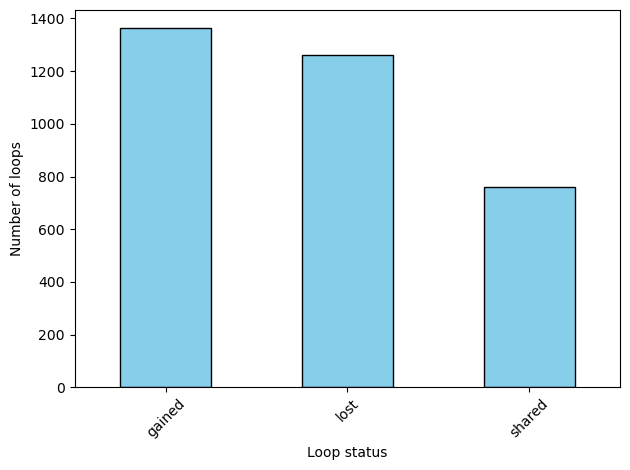

In [56]:
import matplotlib.pyplot as plt

# Count the frequency of each status
status_counts = final_matched_loops['status'].value_counts()

# Plot
status_counts.plot(kind='bar', color='skyblue', edgecolor='black')
#plt.title('Loop Status Distribution')
plt.xlabel('Loop status')
plt.ylabel('Number of loops')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# if TSS bed file have only 94 rows, how can it have more than 94 matched loops??

In [57]:
from mygene import MyGeneInfo
import pandas as pd

# Initialize
mg = MyGeneInfo()

# Strip version numbers from Ensembl transcript IDs
ensembl_tx_ids = final_matched_loops['gene_id'].dropna().str.replace(r'\.\d+$', '', regex=True).unique().tolist()

# Query gene symbols using cleaned transcript IDs
gene_info = mg.querymany(ensembl_tx_ids, scopes='ensembltranscript', fields='symbol', species='human')

# Convert to DataFrame and filter
gene_map_df = pd.DataFrame(gene_info)
if 'symbol' in gene_map_df.columns:
    gene_map_df = gene_map_df[['query', 'symbol']].dropna().drop_duplicates()
    gene_map_df.columns = ['gene_id', 'gene_symbol']

    # Merge with version-stripped IDs
    final_matched_loops['gene_id_novers'] = final_matched_loops['gene_id'].str.replace(r'\.\d+$', '', regex=True)
    final_matched_loops = final_matched_loops.merge(gene_map_df, left_on='gene_id_novers', right_on='gene_id', how='left')
    final_matched_loops.drop(columns=['gene_id_novers'], inplace=True)
    final_matched_loops.rename(columns={'gene_symbol': 'gene_symbol', 'query': 'gene_id'}, inplace=True)
else:
    print("No 'symbol' field found in MyGeneInfo results.")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [58]:
final_matched_loops

,genebody_chr,genebody_start,genebody_end,gene_id_x,score,strand,anchor_chr,anchor_start,anchor_end,genebody_anchor,...,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,anchor_side,distal_chr,distal_start,distal_end,gene_id_y,gene_symbol
0,chr1,22710338,22891765,ENST00000544305.5,0,+,chr1,22762500,22767500,1,...,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500,ENST00000544305,EPHB2
1,chr1,22710338,22922000,ENST00000374630.8,0,+,chr1,22762500,22767500,1,...,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500,ENST00000374630,EPHB2
2,chr1,22710464,22922000,ENST00000400191.7,0,+,chr1,22762500,22767500,1,...,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500,ENST00000400191,EPHB2
3,chr1,22710469,22914770,ENST00000374632.7,0,+,chr1,22762500,22767500,1,...,0.312737,0.295078,-0.006101,-0.017659,left,chr1,22882500,22887500,ENST00000374632,EPHB2
4,chr1,28369081,28459739,ENST00000633371.1,0,+,chr1,28402500,28407500,1,...,0.681454,0.743957,-0.148378,0.062503,left,chr1,28602500,28607500,ENST00000633371,PHACTR4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381,chr12,68324620,68332881,ENST00000430606.3,0,-,chr12,68322500,68327500,2,...,NaN,NaN,NaN,NaN,right,chr12,67352500,67357500,ENST00000430606,MDM1
3382,chr12,68324672,68332757,ENST00000545724.2,0,-,chr12,68322500,68327500,2,...,NaN,NaN,NaN,NaN,right,chr12,67352500,67357500,ENST00000545724,MDM1
3383,chr17,82022804,82031651,ENST00000306688.8,0,+,chr17,82020000,82025000,2,...,0.809561,0.749275,0.023588,-0.060286,right,chr17,81955000,81960000,ENST00000306688,LRRC45
3384,chr17,82022820,82025925,ENST00000583383.5,0,+,chr17,82020000,82025000,2,...,0.809561,0.749275,0.023588,-0.060286,right,chr17,81955000,81960000,ENST00000583383,LRRC45


In [59]:
final_matched_loops.to_csv("merged_loops_with_genes.tsv", sep="\t", index=False)

In [60]:
genestocheck = final_matched_loops["gene_symbol"].dropna().unique().tolist()
genestocheck

['EPHB2',
 'PHACTR4',
 'CDCA8',
 'PTPRF',
 'PCSK9',
 'GABPB2',
 'IL6R',
 'QSOX1',
 'ATP2B4',
 'CLSTN1',
 'ECE1',
 'SLC9A1',
 'GATAD2B',
 'SLC30A1',
 'LTBP1',
 'PCBP1',
 'SLC39A10',
 'ATIC',
 'CKAP2L',
 'SERPINE2',
 'BHLHE40',
 'HRH1',
 'CDCP1',
 'IL17RD',
 'MUC13',
 'LINC00880',
 'LAMP3',
 'PARM1',
 'GAR1',
 'ANK2',
 'SYNPO',
 'HLA-F',
 'ENPP1',
 'HLA-C',
 'EGFR',
 'HIP1',
 'PODXL',
 'PDIA4',
 'CLU',
 'NR4A3',
 'PALM2AKAP2',
 'FRMD3',
 'TNC',
 'NOTCH1',
 'AKR1C3',
 'FAM171A1',
 'PSAP',
 'GOT1',
 'KCNQ1',
 'CAPN5',
 'SESN3',
 'NECTIN1',
 'SIAE',
 'SLC17A8',
 'CHST11',
 'RNFT2',
 'SLC7A1',
 'LGMN',
 'NEO1',
 'CEMIP',
 'IGF1R',
 'EDC3',
 'PYCARD-AS1',
 'CDH3',
 'FA2H',
 'HEXIM1',
 'SCPEP1',
 'SEPTIN9',
 'GAA',
 'TNS4',
 'VAT1',
 'SP6',
 'ADGRE5',
 'CYP2S1',
 'CEACAM5',
 'CEACAM19',
 'TICAM1',
 'INSR',
 'TGFB1',
 'ZC3H4',
 'JPH2',
 'BACE2',
 'PDE9A',
 'APP',
 'SCAF4',
 'SMTN',
 'TIMP3',
 'SUN2',
 'ARMCX4',
 'NSDHL',
 'ZNF185',
 'SRPX',
 'ARHGEF6',
 'LINC02474',
 'SNORA80B',
 'LEKR1',
 'CXC

In [61]:
len(genestocheck)

150

In [62]:
# to see if any genes have many transcripts
final_matched_loops["gene_symbol"].value_counts()

gene_symbol
ANK2          766
PALM2AKAP2    156
SEPTIN9       114
IGF1R         102
APLP2          94
             ... 
GALNT2          1
PSAP            1
BAG3            1
HEXIM1          1
PYCARD-AS1      1
Name: count, Length: 150, dtype: int64

In [36]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [37]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit linear model
model = ols('log2FC ~ C(status)', data=final_matched_loops).fit()

# Run ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                sum_sq      df         F        PR(>F)
C(status)   253.355170     2.0  92.76572  1.210193e-39
Residual   3555.930264  2604.0       NaN           NaN


---